<a href="https://colab.research.google.com/github/R3tromancer/Dynamic-fall-detection-for-edge-devices/blob/TCN/trunk_tcn_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trunk-vector TCN fall detection (v4)
Raw-skeleton augmentation bank, window-relative (causal) normalization, optional MIL windowed training, leave-one-dataset-out evaluation.

Set the options in **CELL 3** (`AUG_PRESET` / `AUG_CUSTOM`, `WINDOW_MODE`, `NORM_SCOPE`, `RUN_MODES`, `SEEDS`), then run all cells. Rerun **CELL 14** after several runs to get the ablation table.

In [ ]:
# Remove the existing mountpoint directory
!rm -rf /content/drive

In [ ]:
# CELL 1 — MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# CELL 2 — IMPORTS
import sys, os, re, csv, json, math, zlib, pickle, random, hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from scipy.signal import savgol_filter
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score


In [ ]:
# CELL 3 — CONFIGURATION
SPLIT_SEED = 42                 # fixes the outer folds and the inner train/val split
SEEDS = [42]            # model seeds (init, shuffling, augmentation draws)

MYDRIVE_ROOT = Path("/content/drive/MyDrive")
PROCESSED_DIR = MYDRIVE_ROOT / "UrProcessedNormed"
GROUPS_CSV = None               # optional CSV with columns "sequence,group" (scene / subject) -> group-aware folds

# ---------------- experiments ----------------
#RUN_MODES = ["all", "ur", "le2i", "ur_to_le2i", "le2i_to_ur"]
RUN_MODES = ["all", "ur", "le2i"]
MODE_TRAIN = {"all": ("ur", "le2i"), "ur": ("ur",), "le2i": ("le2i",),
              "ur_to_le2i": ("ur",), "le2i_to_ur": ("le2i",)}
MODE_TEST = {"all": ("ur", "le2i"), "ur": ("ur",), "le2i": ("le2i",),
             "ur_to_le2i": ("le2i",), "le2i_to_ur": ("ur",)}
FIXED_THRESHOLD = 0.5
RESUME_EXISTING = False
PRINT_EVERY = 10
PLOT_RESULTS = True

# ---------------- augmentation (training data only) ----------------
# mirror        horizontal flip, exact in feature space (GPU, per sample / per bag)
# rotate        in-plane camera roll of the raw joints
# axis_scale    independent x / y scaling of the raw joints (pseudo yaw / pitch, foreshortening)
# shear         x += k*y (vertical lean, keystone-like)
# time_scale    global speed change (0.8x-1.25x)
# time_warp     smooth non-uniform speed change
# joint_noise   Gaussian jitter of the joints, proportional to trunk length (pose-estimator noise)
# joint_dropout random / block joint drop-outs (exercises the fallback ladder)
# frame_dropout random / block missing frames (detector failures)
AUG_PRESETS = {
    "none": [],
    "mirror": ["mirror"],
    "geometry": ["mirror", "rotate", "axis_scale", "shear"],
    "temporal": ["mirror", "time_scale", "time_warp"],
    "robustness": ["mirror", "joint_noise", "joint_dropout", "frame_dropout"],
    "full": ["mirror", "rotate", "axis_scale", "shear", "time_scale", "time_warp",
             "joint_noise", "joint_dropout", "frame_dropout"],
}
AUG_PRESET = "full"
AUG_CUSTOM = None               # e.g. ["mirror", "rotate", "time_scale"] overrides the preset
AUG_ENABLE = list(AUG_CUSTOM) if AUG_CUSTOM is not None else list(AUG_PRESETS[AUG_PRESET])
assert set(AUG_ENABLE) <= set(AUG_PRESETS["full"]), f"unknown augmentation in {AUG_ENABLE}"
USE_MIRROR_AUG = "mirror" in AUG_ENABLE
RAW_AUGS = [a for a in AUG_ENABLE if a != "mirror"]
MIRROR_PROB = 0.5
MIRROR_TTA = True               # average original + mirrored prediction at inference (only if mirror is enabled)
AUG_BANK_SIZE = 12              # augmented variants generated per TRAINING sequence and seed
AUG_ORIGINAL_P = 0.25           # probability of using the un-augmented sequence in a training step
AUG_PARAMS = {
    "p": {"rotate": 0.5, "axis_scale": 0.5, "shear": 0.3, "time_scale": 0.5, "time_warp": 0.3,
          "joint_noise": 0.5, "joint_dropout": 0.4, "frame_dropout": 0.4},
    "rotate_deg": 12.0,
    "scale_x": [0.7, 1.15], "scale_y": [0.8, 1.2], "shear": 0.15,
    "time_scale": [0.8, 1.25], "time_warp_rate": 0.25, "time_warp_seg": 40,
    "noise_sigma": [0.01, 0.04],
    "joint_drop_p": [0.02, 0.08], "joint_block_len": [5, 25],
    "frame_drop": [0.02, 0.12], "frame_block_len": [3, 20],
}

# ---------------- windowing / normalization ----------------
WINDOW_MODE = "none"             # "none": whole sequence | "mil": sliding windows + multiple-instance pooling
WINDOW_LEN = 100                # frames at TARGET_FPS (4 s)
WINDOW_STRIDE = 25              # frames (1 s)
MIL_POOL = "topk"               # "max" | "topk" | "lse"  (sequence score from window scores)
MIL_K = 3
MIL_LSE_R = 2.0
NORM_SCOPE = "sequence"           # "window": statistics of each window only (causal-compatible)
                                # "sequence": statistics of the whole sequence (non-causal, ablation)
MIN_SCALE_PX = 2.0

# ---------------- preprocessing ----------------
TARGET_FPS = 25.0
SOURCE_FPS = {"le2i": 25.0, "ur": 30.0}
NUM_JOINTS = 13
HARD_CONF = 0.5
SOFT_CONF = 0.3
MIN_CLEAN_FRAMES = 5
MIN_OUTPUT_FRAMES = 16
SG_WINDOW = 7
SG_POLY = 2

# ---------------- features: (channel name, mirror sign, normalization kind) ----------------
# kinds: pos_x / pos_y -> (v - window centre) / trunk length ; len -> v / trunk length ; none -> unchanged
FEATURE_GROUPS = {
    "start_pos":   [("start_x", -1, "pos_x"), ("start_y", 1, "pos_y")],
    "end_pos":     [("end_x", -1, "pos_x"), ("end_y", 1, "pos_y")],
    "center_pos":  [("center_x", -1, "pos_x"), ("center_y", 1, "pos_y")],
    "orientation": [("axis_ux", -1, "none"), ("axis_uy", 1, "none"), ("trunk_length", 1, "len")],
    "start_vel":   [("start_vx", -1, "len"), ("start_vy", 1, "len")],
    "end_vel":     [("end_vx", -1, "len"), ("end_vy", 1, "len")],
    "center_vel":  [("center_vx", -1, "len"), ("center_vy", 1, "len")],
    "center_acc":  [("center_ax", -1, "len"), ("center_ay", 1, "len")],
    "angular_vel": [("axis_angular_velocity", -1, "none")],
    "bbox":        [("bbox_width", 1, "len"), ("bbox_height", 1, "len"), ("bbox_log_aspect", 1, "none")],
    "quality":     [("unreliable_flag", 1, "none")],
}
SELECTED_FEATURES = ["start_pos", "end_pos", "orientation", "center_vel", "bbox", "center_acc", "center_pos"]

assert len(SELECTED_FEATURES) > 0
for g in SELECTED_FEATURES:
    assert g in FEATURE_GROUPS, f"Unknown group {g}; available: {list(FEATURE_GROUPS)}"
assert all(m in MODE_TRAIN and m in MODE_TEST for m in RUN_MODES)
assert WINDOW_MODE in ("none", "mil") and MIL_POOL in ("max", "topk", "lse") and NORM_SCOPE in ("window", "sequence")

_COLS = [c for g in SELECTED_FEATURES for c in FEATURE_GROUPS[g]]
SELECTED_FEATURE_NAMES = [c[0] for c in _COLS]
MIRROR_SIGN = np.array([c[1] for c in _COLS], dtype=np.float32)
POS_X_COLS = np.array([i for i, c in enumerate(_COLS) if c[2] == "pos_x"], dtype=np.int64)
POS_Y_COLS = np.array([i for i, c in enumerate(_COLS) if c[2] == "pos_y"], dtype=np.int64)
LEN_COLS = np.array([i for i, c in enumerate(_COLS) if c[2] == "len"], dtype=np.int64)
INPUT_CHANNELS = len(_COLS)
SAFE_FEATURE_TAG = re.sub(r"[^A-Za-z0-9_+\-]", "_", "+".join(SELECTED_FEATURES))

# ---------------- model / training ----------------
FINAL_EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
DROPOUT = 0.5
TCN_HIDDEN = 64
TCN_KERNEL = 11                  # must be odd
TCN_DILATIONS = [1, 2, 4, 8]
GRAD_CLIP = 1.0
NUM_CLASSES = 2
VALIDATION_RATIO = 0.20
LABEL_SMOOTHING = 0.05

assert TCN_KERNEL % 2 == 1 and SG_WINDOW <= MIN_OUTPUT_FRAMES

# ---------------- run folder (hash of everything that changes results) ----------------
RUN_CONFIG = {
    "features": SELECTED_FEATURES, "aug_enable": AUG_ENABLE, "aug_params": AUG_PARAMS,
    "aug_bank": AUG_BANK_SIZE, "aug_original_p": AUG_ORIGINAL_P, "mirror_prob": MIRROR_PROB,
    "mirror_tta": MIRROR_TTA, "window_mode": WINDOW_MODE, "window_len": WINDOW_LEN,
    "window_stride": WINDOW_STRIDE, "mil_pool": MIL_POOL, "mil_k": MIL_K, "mil_lse_r": MIL_LSE_R,
    "norm_scope": NORM_SCOPE, "epochs": FINAL_EPOCHS, "batch": BATCH_SIZE, "lr": LEARNING_RATE,
    "wd": WEIGHT_DECAY, "dropout": DROPOUT, "hidden": TCN_HIDDEN, "kernel": TCN_KERNEL,
    "dilations": TCN_DILATIONS, "label_smoothing": LABEL_SMOOTHING, "grad_clip": GRAD_CLIP,
    "split_seed": SPLIT_SEED, "val_ratio": VALIDATION_RATIO, "groups_csv": str(GROUPS_CSV),
    "target_fps": TARGET_FPS, "sg": [SG_WINDOW, SG_POLY], "conf": [HARD_CONF, SOFT_CONF],
}
RUN_HASH = hashlib.md5(json.dumps(RUN_CONFIG, sort_keys=True).encode()).hexdigest()[:8]
AUG_TAG = AUG_PRESET if AUG_CUSTOM is None else "custom"
WINDOW_TAG = "seq" if WINDOW_MODE == "none" else f"mil{WINDOW_LEN}-{MIL_POOL}"
RUN_NAME = f"{SAFE_FEATURE_TAG}__aug-{AUG_TAG}__win-{WINDOW_TAG}-{NORM_SCOPE}__{RUN_HASH}"

EXPERIMENT_ROOT = MYDRIVE_ROOT / "TrunkTCN_v4"
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)


def mode_dirs(mode):
    root = EXPERIMENT_ROOT / f"{RUN_NAME}__{mode}"
    return root / "checkpoints", root / "results"


print("Dataset   :", PROCESSED_DIR)
print("Features  :", SELECTED_FEATURES, f"({INPUT_CHANNELS} channels)")
print("Augment   :", AUG_ENABLE if AUG_ENABLE else "none",
      f"| bank {AUG_BANK_SIZE} variants/sequence" if RAW_AUGS else "")
print("Windowing :", WINDOW_MODE, f"(len {WINDOW_LEN}, stride {WINDOW_STRIDE}, pool {MIL_POOL})" if WINDOW_MODE == "mil" else "",
      "| normalization scope:", NORM_SCOPE)
print("Modes     :", RUN_MODES, "| seeds:", SEEDS)
print("Run name  :", RUN_NAME)


Dataset   : /content/drive/MyDrive/UrProcessedNormed
Features  : ['start_pos', 'end_pos', 'orientation', 'center_vel', 'bbox', 'center_acc', 'center_pos'] (16 channels)
Augment   : ['mirror', 'rotate', 'axis_scale', 'shear', 'time_scale', 'time_warp', 'joint_noise', 'joint_dropout', 'frame_dropout'] | bank 12 variants/sequence
Windowing : none  | normalization scope: sequence
Modes     : ['all', 'ur', 'le2i'] | seeds: [42]
Run name  : start_pos+end_pos+orientation+center_vel+bbox+center_acc+center_pos__aug-full__win-seq-sequence__d1942e07


In [ ]:
# CELL 4 — ENVIRONMENT
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MIRROR_SIGN_T = torch.tensor(MIRROR_SIGN, dtype=torch.float32, device=DEVICE).view(1, -1, 1)
print("PyTorch:", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu")
assert PROCESSED_DIR.is_dir(), f"Missing dataset directory: {PROCESSED_DIR}"


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)


PyTorch: 2.11.0+cu128 | device: cuda | Tesla T4


In [ ]:
# CELL 5 — LOAD RAW SKELETONS (raw pixel coordinates, confidences, timestamps)
def source_info(data):
    if "frame_paths" in data:
        return "ur", SOURCE_FPS["ur"]
    if "frame_indices" in data:
        return "le2i", SOURCE_FPS["le2i"]
    raise KeyError("PKL has neither 'frame_paths' (UR Fall) nor 'frame_indices' (Le2i).")


def get_frame_numbers(data):
    if "frame_paths" in data:
        frames = [int(re.search(r"-(\d+)\.\w+$", str(p)).group(1)) for p in data["frame_paths"]]
    else:
        frames = list(data["frame_indices"])
    return np.asarray(frames, dtype=np.int64)


processed_files = sorted(p for p in PROCESSED_DIR.glob("*.pkl") if p.is_file())
assert processed_files, f"No .pkl files in {PROCESSED_DIR}"

raw_store, sequence_order = {}, []
for file_path in processed_files:
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    missing = {"sequence", "label", "skeleton", "confidence"} - set(data.keys())
    assert not missing, f"Missing keys in {file_path.name}: {sorted(missing)}"
    label = int(data["label"])
    assert label in (0, 1), f"Bad label in {file_path.name}: {label}"
    sk = np.asarray(data["skeleton"], dtype=np.float64)
    cf = np.asarray(data["confidence"], dtype=np.float64)
    T = sk.shape[0]
    assert sk.shape == (T, NUM_JOINTS, 2) and cf.shape == (T, NUM_JOINTS), file_path.name
    assert np.isfinite(sk).all() and np.isfinite(cf).all(), f"Non-finite values in {file_path.name}"
    dataset_name, fps = source_info(data)
    frames = get_frame_numbers(data)
    assert len(frames) == T and np.all(np.diff(frames) > 0), f"Bad frame numbers in {file_path.name}"
    name = str(data["sequence"])
    assert name not in raw_store, f"Duplicate sequence name {name}"
    raw_store[name] = {"sk": sk, "cf": cf, "t": frames / fps, "label": label, "dataset": dataset_name}
    sequence_order.append(name)

for ds in ("ur", "le2i"):
    for lb, lname in ((0, "ADL"), (1, "Fall")):
        print(f"{ds:5s} {lname:5s}: {sum(1 for r in raw_store.values() if r['dataset'] == ds and r['label'] == lb)}")


ur    ADL  : 40
ur    Fall : 30
le2i  ADL  : 59
le2i  Fall : 124


In [ ]:
# CELL 6 — TRUNK NODES, FEATURE DERIVATION AND RAW-SKELETON AUGMENTATION
SH, HIP, LEG = [1, 4], [7, 10], [8, 9, 11, 12]      # neck (0) is derived from the shoulders -> ignored


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-6 else None


def _group_pts(sk, cf, joints, thr):
    """Confidence-weighted mean of the joints with cf >= thr, for every frame. Returns (points [T,2], valid [T])."""
    c = cf[:, joints]
    w = c * (c >= thr)
    ws = w.sum(axis=1)
    pts = (sk[:, joints, :] * w[:, :, None]).sum(axis=1) / np.maximum(ws, 1e-12)[:, None]
    return pts, ws > 0


def estimate_nodes(sk, cf):
    """S (hips), E (shoulders) [T,2] and quality Q [T]:
       0 clean | 1 reconstructed from trunk length + leg direction | 2 low-confidence detections
       | 3 PCA axis | 4 unresolved (temporal fill later)."""
    T = len(sk)
    S = np.full((T, 2), np.nan)
    E = S.copy()
    Q = np.full(T, 4, dtype=np.int64)
    s0, sok = _group_pts(sk, cf, HIP, HARD_CONF)
    e0, eok = _group_pts(sk, cf, SH, HARD_CONF)
    q0 = sok & eok
    S[q0], E[q0], Q[q0] = s0[q0], e0[q0], 0
    s2, s2ok = _group_pts(sk, cf, HIP, SOFT_CONF)
    e2, e2ok = _group_pts(sk, cf, SH, SOFT_CONF)
    if q0.sum() >= MIN_CLEAN_FRAMES:
        L_ref = float(np.median(np.linalg.norm(E[q0] - S[q0], axis=1)))
    else:
        both = s2ok & e2ok
        if both.sum() < MIN_CLEAN_FRAMES:
            raise ValueError("cannot estimate trunk length")
        L_ref = float(np.median(np.linalg.norm(e2[both] - s2[both], axis=1)))
    if L_ref < 1e-3:
        raise ValueError("degenerate trunk length")
    lc, lok = _group_pts(sk, cf, LEG, HARD_CONF)

    last_q0 = np.maximum.accumulate(np.where(q0, np.arange(T), -1))
    prev_idx, prev_dir = -1, None                    # latest resolved fallback frame and its direction
    for t in np.flatnonzero(~q0):
        j0 = int(last_q0[t - 1]) if t > 0 else -1    # latest clean frame before t
        pd = unit(E[j0] - S[j0]) if j0 > prev_idx else prev_dir
        s = s0[t] if sok[t] else None
        e = e0[t] if eok[t] else None
        l = lc[t] if lok[t] else None
        if s is None and e is not None and l is not None and unit(l - e) is not None:
            S[t], E[t], Q[t] = e + L_ref * unit(l - e), e, 1
        elif e is None and s is not None and l is not None and unit(s - l) is not None:
            S[t], E[t], Q[t] = s, s + L_ref * unit(s - l), 1
        elif s2ok[t] and e2ok[t]:
            S[t], E[t], Q[t] = s2[t], e2[t], 2
        elif pd is not None and (cf[t] >= SOFT_CONF).sum() >= 3:
            idx = np.flatnonzero(cf[t] >= SOFT_CONF)
            ctr = sk[t, idx].mean(axis=0)
            a = np.linalg.svd(sk[t, idx] - ctr)[2][0]
            a = a if a @ pd >= 0 else -a
            S[t], E[t], Q[t] = ctr - 0.5 * L_ref * a, ctr + 0.5 * L_ref * a, 3
        if Q[t] < 4:
            prev_idx, prev_dir = int(t), unit(E[t] - S[t])
    return S, E, Q


def bbox_series(sk, cf):
    """Width / height of the confident joints per frame (NaN if fewer than 3 usable joints)."""
    m_hard, m_soft = cf >= HARD_CONF, cf >= SOFT_CONF
    use = np.where((m_hard.sum(axis=1) >= 4)[:, None], m_hard, m_soft)
    big = 1e18
    W = np.where(use, sk[:, :, 0], -big).max(axis=1) - np.where(use, sk[:, :, 0], big).min(axis=1)
    H = np.where(use, sk[:, :, 1], -big).max(axis=1) - np.where(use, sk[:, :, 1], big).min(axis=1)
    bad = use.sum(axis=1) < 3
    W[bad], H[bad] = np.nan, np.nan
    return W, H


def sg(P, deriv=0):
    return savgol_filter(np.asarray(P, dtype=np.float64), SG_WINDOW, SG_POLY,
                         deriv=deriv, delta=1.0, axis=0, mode="interp")


def derive_features(sk, cf, times):
    """Raw joints [T,13,2] (pixels), confidences [T,13], timestamps [T] (s, increasing)
       -> features on the TARGET_FPS grid, still in pixel units (normalization happens per window later)."""
    if len(times) < 2:
        raise ValueError("too few frames")
    dts = np.diff(times)
    if np.any(dts <= 0):
        raise ValueError("timestamps must increase")
    S, E, Q = estimate_nodes(sk, cf)
    ok = ~np.isnan(S[:, 0])
    if ok.sum() < 2:
        raise ValueError("fewer than 2 resolved frames")
    Wb, Hb = bbox_series(sk, cf)
    okb = ~np.isnan(Wb)
    if okb.sum() < 2:
        raise ValueError("bounding box unavailable")

    tgrid = np.arange(times[0], times[-1] + 1e-9, 1.0 / TARGET_FPS)
    if len(tgrid) < MIN_OUTPUT_FRAMES:
        raise ValueError(f"only {len(tgrid)} frames after resampling")

    def interp2(P):
        return np.stack([np.interp(tgrid, times[ok], P[ok, k]) for k in range(2)], axis=1)

    S_i, E_i = interp2(S), interp2(E)
    W_i = np.interp(tgrid, times[okb], Wb[okb])
    H_i = np.interp(tgrid, times[okb], Hb[okb])

    dt_med = float(np.median(dts))
    j = np.clip(np.searchsorted(times, tgrid), 1, len(times) - 1)
    nearest = np.where(np.abs(times[j - 1] - tgrid) <= np.abs(times[j] - tgrid), j - 1, j)
    Q_i = Q[nearest].copy()
    Q_i[np.abs(times[nearest] - tgrid) > 0.75 * dt_med] = 4          # interpolated across a gap
    unreliable = (Q_i > 0).astype(np.float64)

    C_i = (S_i + E_i) / 2.0
    Ss, Es, Cs = sg(S_i), sg(E_i), sg(C_i)
    a = Es - Ss
    L = np.linalg.norm(a, axis=1)
    u = a / np.maximum(L, 1e-6)[:, None]
    angle = np.unwrap(np.arctan2(u[:, 1], u[:, 0]))
    Ws, Hs = np.clip(sg(W_i), 0, None), np.clip(sg(H_i), 0, None)
    eps = 0.1 * max(float(np.median(L)), 1.0)

    groups = {
        "start_pos":   Ss,
        "end_pos":     Es,
        "center_pos":  Cs,
        "orientation": np.column_stack([u, L]),
        "start_vel":   sg(S_i, 1),
        "end_vel":     sg(E_i, 1),
        "center_vel":  sg(C_i, 1),
        "center_acc":  sg(C_i, 2),
        "angular_vel": sg(angle[:, None], 1),
        "bbox":        np.column_stack([Ws, Hs, np.log((Ws + eps) / (Hs + eps))]),
        "quality":     unreliable[:, None],
    }
    groups = {k: np.asarray(v, dtype=np.float32) for k, v in groups.items()}
    for k, v in groups.items():
        assert v.shape == (len(tgrid), len(FEATURE_GROUPS[k])), f"{k}: {v.shape}"
        assert np.isfinite(v).all(), f"non-finite values in {k}"
    return {"groups": groups, "scale": L.astype(np.float32), "center": Cs.astype(np.float32),
            "num_frames": len(tgrid), "quality_counts": np.bincount(Q_i, minlength=5)}


def est_trunk_len(sk):
    L = float(np.median(np.linalg.norm(sk[:, SH, :].mean(axis=1) - sk[:, HIP, :].mean(axis=1), axis=1)))
    return L if L > 1e-3 else 1.0


def augment_raw(sk, cf, times, rng):
    """Random view / noise / dropout / timing perturbation of ONE sequence, applied to the raw joints BEFORE
       feature derivation (so velocities, orientation, bbox, quality flags stay consistent).
       Uses nothing but this sequence and `rng`; the policy does not depend on the label."""
    P, p = AUG_PARAMS, AUG_PARAMS["p"]
    sk, cf, times = sk.copy(), cf.copy(), times.copy()
    T = len(sk)
    ctr = sk.reshape(-1, 2).mean(axis=0)

    M = np.eye(2)                                        # viewpoint: scale -> shear -> roll
    if "axis_scale" in RAW_AUGS and rng.random() < p["axis_scale"]:
        M = np.diag([rng.uniform(*P["scale_x"]), rng.uniform(*P["scale_y"])]) @ M
    if "shear" in RAW_AUGS and rng.random() < p["shear"]:
        M = np.array([[1.0, rng.uniform(-P["shear"], P["shear"])], [0.0, 1.0]]) @ M
    if "rotate" in RAW_AUGS and rng.random() < p["rotate"]:
        th = np.deg2rad(rng.uniform(-P["rotate_deg"], P["rotate_deg"]))
        M = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]]) @ M
    sk = (sk - ctr) @ M.T + ctr
    L0 = est_trunk_len(sk)

    if "joint_noise" in RAW_AUGS and rng.random() < p["joint_noise"]:
        sk = sk + rng.normal(0.0, rng.uniform(*P["noise_sigma"]) * L0, sk.shape)

    if "joint_dropout" in RAW_AUGS and rng.random() < p["joint_dropout"]:
        drop = rng.random(cf.shape) < rng.uniform(*P["joint_drop_p"])
        if rng.random() < 0.5:                           # occlude one body part for a while
            grp = [HIP, SH, LEG][int(rng.integers(3))]
            n = int(rng.integers(P["joint_block_len"][0], P["joint_block_len"][1] + 1))
            a = int(rng.integers(0, max(T - n, 0) + 1))
            drop[a:a + n, grp] = True
        cf[drop] = 0.0
        sk[drop] += rng.normal(0.0, 0.10 * L0, size=(int(drop.sum()), 2))

    if "time_scale" in RAW_AUGS and rng.random() < p["time_scale"]:
        times = times[0] + (times - times[0]) * rng.uniform(*P["time_scale"])
    if "time_warp" in RAW_AUGS and rng.random() < p["time_warp"]:
        seg = max(int(P["time_warp_seg"]), 2)
        n_seg = T // seg + 1
        rate = 1.0 + rng.uniform(-P["time_warp_rate"], P["time_warp_rate"], size=n_seg)
        dt = np.diff(times) * rate[np.minimum(np.arange(T - 1) // seg, n_seg - 1)]
        times = times[0] + np.concatenate([[0.0], np.cumsum(dt)])

    if "frame_dropout" in RAW_AUGS and rng.random() < p["frame_dropout"]:
        keep = rng.random(T) >= rng.uniform(*P["frame_drop"])
        if rng.random() < 0.5:
            n = int(rng.integers(P["frame_block_len"][0], P["frame_block_len"][1] + 1))
            a = int(rng.integers(0, max(T - n, 0) + 1))
            keep[a:a + n] = False
        keep[0] = keep[-1] = True
        if keep.sum() >= max(MIN_OUTPUT_FRAMES, int(0.6 * T)):
            sk, cf, times = sk[keep], cf[keep], times[keep]
    return sk, cf, times


def build_bank(names, seed):
    """Augmented variants for the given (TRAINING) sequences only. Deterministic per (seed, sequence)."""
    bank = {}
    for n in names:
        rng = np.random.default_rng([int(seed), zlib.crc32(n.encode())])
        r, variants = raw_store[n], []
        for _ in range(AUG_BANK_SIZE):
            try:
                sk, cf, t = augment_raw(r["sk"], r["cf"], r["t"], rng)
                variants.append(derive_features(sk, cf, t))
            except ValueError:
                continue
        bank[n] = variants
    return bank


In [ ]:
# CELL 7 — DERIVE FEATURES OF THE ORIGINAL SEQUENCES
orig_store, skipped = {}, []
for n_ in sequence_order:
    try:
        orig_store[n_] = derive_features(raw_store[n_]["sk"], raw_store[n_]["cf"], raw_store[n_]["t"])
    except Exception as exc:
        skipped.append((n_, str(exc)))
print(f"Usable sequences: {len(orig_store)} | skipped: {len(skipped)}")
for n_, reason in skipped:
    print(f"   skipped {n_}: {reason}")

sequence_names = [n_ for n_ in sequence_order if n_ in orig_store]
label_by_sequence = {n_: raw_store[n_]["label"] for n_ in sequence_names}
dataset_by_sequence = {n_: raw_store[n_]["dataset"] for n_ in sequence_names}

level_names = ["clean", "reconstructed", "low-conf", "PCA", "temporal fill"]
for ds in ("ur", "le2i"):
    ent = [orig_store[n_] for n_ in sequence_names if dataset_by_sequence[n_] == ds]
    if ent:
        tot = np.sum([e["quality_counts"] for e in ent], axis=0)
        print(f"  {ds:5s}: " + " | ".join(f"{a}={100 * b:.1f}%" for a, b in zip(level_names, tot / tot.sum())))


Usable sequences: 253 | skipped: 0
  ur   : clean=89.6% | reconstructed=0.4% | low-conf=0.0% | PCA=0.0% | temporal fill=10.1%
  le2i : clean=96.0% | reconstructed=0.1% | low-conf=0.0% | PCA=0.0% | temporal fill=3.9%


In [ ]:
# CELL 8 — WINDOWS, NORMALIZATION, DATASETS
def pack_source(F):
    X = np.concatenate([F["groups"][g] for g in SELECTED_FEATURES], axis=1).astype(np.float32)
    return X, F["scale"], F["center"]


def norm_ref(scale, center):
    """Reference size (trunk length, px) and centre of ONE window / sequence — uses only those frames."""
    L = float(np.median(scale))
    if not np.isfinite(L) or L < MIN_SCALE_PX:
        L = MIN_SCALE_PX
    return L, center.mean(axis=0)


def apply_norm(X, L, c):
    Y = X.copy()
    Y[:, POS_X_COLS] = (X[:, POS_X_COLS] - c[0]) / L
    Y[:, POS_Y_COLS] = (X[:, POS_Y_COLS] - c[1]) / L
    Y[:, LEN_COLS] = X[:, LEN_COLS] / L
    return Y


def window_starts(T, W, stride, offset=0):
    if T <= W:
        return [0]
    starts = list(range(offset, T - W + 1, stride))
    if not starts or starts[-1] != T - W:
        starts.append(T - W)                             # always cover the end of the sequence
    return starts


class SeqDataset(Dataset):
    """One item = one sequence: whole sequence [C,T] (WINDOW_MODE 'none') or a bag of windows [n,C,W] ('mil').
       Training items may come from the augmentation bank; validation/test items never do."""

    def __init__(self, names, orig, bank=None, train=False, mean=None, std=None):
        self.names = list(names)
        self.orig = {n: pack_source(orig[n]) for n in self.names}
        self.var = {n: [pack_source(F) for F in (bank or {}).get(n, [])] for n in self.names}
        if bank:                                         # a bank may only contain this split's own sequences
            assert set(bank) <= set(self.names), "augmentation bank contains sequences outside this split"
        self.labels = [label_by_sequence[n] for n in self.names]
        self.train, self.mean, self.std = train, mean, std

    def set_norm(self, mean, std):
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.names)

    def _pick(self, n):
        if self.train and self.var[n] and np.random.rand() >= AUG_ORIGINAL_P:
            return self.var[n][np.random.randint(len(self.var[n]))]
        return self.orig[n]

    def _windows(self, src, random_offset):
        X, sc, ce = src
        T = len(X)
        if WINDOW_MODE == "none":
            segs = [(0, T)]
        else:
            off = np.random.randint(0, WINDOW_STRIDE) if random_offset else 0
            segs = [(s, min(s + WINDOW_LEN, T)) for s in window_starts(T, WINDOW_LEN, WINDOW_STRIDE, off)]
        seq_ref = norm_ref(sc, ce) if NORM_SCOPE == "sequence" else None
        out = []
        for a, b in segs:
            L, c = seq_ref if seq_ref is not None else norm_ref(sc[a:b], ce[a:b])
            out.append(apply_norm(X[a:b], L, c))
        return out

    def raw_rows(self, i):                               # normalized, not standardized; original data only
        return self._windows(self.orig[self.names[i]], random_offset=False)

    def __getitem__(self, i):
        n, y = self.names[i], self.labels[i]
        wins = self._windows(self._pick(n) if self.train else self.orig[n], random_offset=self.train)
        if self.mean is not None:
            wins = [(w - self.mean) / self.std for w in wins]
        if WINDOW_MODE == "none":
            return (torch.from_numpy(np.ascontiguousarray(wins[0].T, dtype=np.float32)),
                    torch.tensor(y, dtype=torch.long), n)
        Xw = np.zeros((len(wins), INPUT_CHANNELS, WINDOW_LEN), np.float32)
        Mw = np.zeros((len(wins), 1, WINDOW_LEN), np.float32)
        for j, w in enumerate(wins):
            Xw[j, :, :len(w)] = w.T
            Mw[j, 0, :len(w)] = 1.0
        return torch.from_numpy(Xw), torch.from_numpy(Mw), torch.tensor(y, dtype=torch.long), n


def compute_stats(ds):
    """Per-channel mean/std over the (normalized) TRAINING sequences only; symmetric if mirror is used."""
    rows = np.concatenate([w for i in range(len(ds)) for w in ds.raw_rows(i)], axis=0)
    if USE_MIRROR_AUG:
        rows = np.concatenate([rows, rows * MIRROR_SIGN[None, :]], axis=0)
    mean = rows.mean(axis=0).astype(np.float32)
    std = rows.std(axis=0).astype(np.float32)
    std[std < 1e-6] = 1.0
    return mean, std


def seq_collate(batch):                                  # WINDOW_MODE "none"
    xs, ys, nm = [b[0] for b in batch], [b[1] for b in batch], [b[2] for b in batch]
    B, C, max_T = len(xs), xs[0].shape[0], max(x.shape[1] for x in xs)
    X, mask = torch.zeros(B, C, max_T), torch.zeros(B, 1, max_T)
    for i, x in enumerate(xs):
        X[i, :, :x.shape[1]] = x
        mask[i, 0, :x.shape[1]] = 1.0
    return X, mask, torch.stack(ys), None, nm


def bag_collate(batch):                                  # WINDOW_MODE "mil": all windows of the batch, flattened
    counts = [b[0].shape[0] for b in batch]
    return (torch.cat([b[0] for b in batch]), torch.cat([b[1] for b in batch]),
            torch.stack([b[2] for b in batch]), counts, [b[3] for b in batch])


def make_loader(dataset, shuffle):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0,
                      pin_memory=(DEVICE.type == "cuda"), drop_last=False,
                      collate_fn=seq_collate if WINDOW_MODE == "none" else bag_collate)


In [ ]:
# CELL 9 — RESIDUAL TCN + MIL POOLING
class ChannelNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ln = nn.LayerNorm(channels)

    def forward(self, x):
        return self.ln(x.transpose(1, 2)).transpose(1, 2)


class ResidualTCNBlock(nn.Module):
    def __init__(self, channels, kernel, dilation, dropout):
        super().__init__()
        pad = dilation * (kernel - 1) // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel, padding=pad, dilation=dilation)
        self.norm1 = ChannelNorm(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel, padding=pad, dilation=dilation)
        self.norm2 = ChannelNorm(channels)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        h = self.drop(self.act(self.norm1(self.conv1(x * mask))))
        h = self.norm2(self.conv2(h * mask))
        return self.act(x + h) * mask


class TrunkTCN(nn.Module):
    def __init__(self, in_channels, hidden, kernel, dilations, dropout, num_classes):
        super().__init__()
        self.inp = nn.Conv1d(in_channels, hidden, 1)
        self.blocks = nn.ModuleList([ResidualTCNBlock(hidden, kernel, d, dropout) for d in dilations])
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2 * hidden, num_classes))

    def forward(self, x, mask):                          # x [B,C,T], mask [B,1,T]
        x = self.inp(x * mask) * mask
        for block in self.blocks:
            x = block(x, mask)
        x_max = x.masked_fill(mask == 0, -1e9).max(dim=2).values
        x_mean = (x * mask).sum(dim=2) / mask.sum(dim=2).clamp(min=1.0)
        return self.head(torch.cat([x_max, x_mean], dim=1))


def make_model(device=None):
    return TrunkTCN(INPUT_CHANNELS, TCN_HIDDEN, TCN_KERNEL, TCN_DILATIONS, DROPOUT, NUM_CLASSES).to(device or DEVICE)


def mil_pool(margin, counts):
    """Window scores (fall-vs-ADL logit margin) -> one score per sequence."""
    outs = []
    for m in torch.split(margin, counts):
        if MIL_POOL == "max":
            outs.append(m.max())
        elif MIL_POOL == "topk":
            outs.append(m.topk(min(MIL_K, m.numel())).values.mean())
        else:                                            # smooth max: (1/r) log mean exp(r m)
            outs.append((torch.logsumexp(MIL_LSE_R * m, dim=0) - math.log(m.numel())) / MIL_LSE_R)
    return torch.stack(outs)


def forward_batch(model, X, mask, counts, sign, tta):
    logits = model(X * mask, mask)
    if tta:                                              # deterministic, label-free test-time augmentation
        logits = (logits + model((X * sign) * mask, mask)) / 2.0
    if counts is None:
        return logits
    margin = logits[:, 1] - logits[:, 0]
    pooled = mil_pool(margin, counts)
    return torch.stack([-pooled / 2.0, pooled / 2.0], dim=1)


def mirror_batch(X, n_bags, counts):
    flip = (torch.rand(n_bags, device=X.device) < MIRROR_PROB).float()
    if counts is not None:                               # every window of a bag is flipped consistently
        flip = torch.repeat_interleave(flip, torch.tensor(counts, device=X.device))
    f = flip.view(-1, 1, 1)
    return X * (1.0 - f + f * MIRROR_SIGN_T)


_m = make_model()
print("Trainable params:", f"{sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m


Trainable params: 363,330


In [ ]:
# CELL 10 — FOLDS (one split of all sequences, filtered per experiment) + LEAKAGE AUDIT
def make_folds_all():
    labels = np.array([label_by_sequence[n_] for n_ in sequence_names], dtype=np.int64)
    if GROUPS_CSV:
        with open(GROUPS_CSV, newline="") as f:
            gmap = {r["sequence"]: r["group"] for r in csv.DictReader(f)}
        missing = [n_ for n_ in sequence_names if n_ not in gmap]
        assert not missing, f"GROUPS_CSV has no group for {missing[:5]}"
        split = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SPLIT_SEED).split(
            sequence_names, labels, [gmap[n_] for n_ in sequence_names])
    else:
        split = StratifiedKFold(n_splits=3, shuffle=True, random_state=SPLIT_SEED).split(sequence_names, labels)
    out = []
    for fold_id, (tr, te) in enumerate(split, start=1):
        outer = [sequence_names[i] for i in tr]
        lab = np.array([label_by_sequence[n_] for n_ in outer], dtype=np.int64)
        train_seq, val_seq = train_test_split(outer, test_size=VALIDATION_RATIO, random_state=SPLIT_SEED, stratify=lab)
        out.append({"fold": fold_id, "outer_train": outer, "train_sequences": list(train_seq),
                    "validation_sequences": list(val_seq), "test_sequences": [sequence_names[i] for i in te]})
    return out


folds_all = make_folds_all()


def build_folds(mode):
    """'all' keeps the fold's own train/val/test. Other modes keep only the sequences of MODE_TRAIN datasets in
       train/val (inner val split redrawn, stratified) and of MODE_TEST datasets in test."""
    keep_train, keep_test = set(MODE_TRAIN[mode]), set(MODE_TEST[mode])
    out = []
    for f in folds_all:
        if mode == "all":
            tr, val = f["train_sequences"], f["validation_sequences"]
        else:
            outer = [n_ for n_ in f["outer_train"] if dataset_by_sequence[n_] in keep_train]
            lab = np.array([label_by_sequence[n_] for n_ in outer], dtype=np.int64)
            tr, val = train_test_split(outer, test_size=VALIDATION_RATIO, random_state=SPLIT_SEED, stratify=lab)
        out.append({"fold": f["fold"], "train_sequences": list(tr), "validation_sequences": list(val),
                    "test_sequences": [n_ for n_ in f["test_sequences"] if dataset_by_sequence[n_] in keep_test]})
    return out


def audit_split(mode, fold):
    """Leakage guards: disjoint splits; cross-dataset modes never train on the test dataset."""
    tr, va, te = set(fold["train_sequences"]), set(fold["validation_sequences"]), set(fold["test_sequences"])
    assert not (tr & va) and not (tr & te) and not (va & te), "train/val/test overlap"
    assert tr and va and te, "empty split"
    if set(MODE_TRAIN[mode]).isdisjoint(MODE_TEST[mode]):
        assert not ({dataset_by_sequence[n_] for n_ in tr | va} & {dataset_by_sequence[n_] for n_ in te}), \
            "cross-dataset mode leaks the test dataset into training"


def describe_folds(mode, fl):
    def c(seqs):
        l = [label_by_sequence[n_] for n_ in seqs]
        return f"{len(l)} (fall={sum(l)}, ADL={len(l) - sum(l)})"
    for f in fl:
        audit_split(mode, f)
        print(f"  [{mode}] fold {f['fold']}: train {c(f['train_sequences'])} | "
              f"val {c(f['validation_sequences'])} | test {c(f['test_sequences'])}")


In [ ]:
# CELL 11 — TRAINING / EVALUATION
train_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
eval_criterion = nn.CrossEntropyLoss()


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    tta = USE_MIRROR_AUG and MIRROR_TTA
    names_, ys, probs, loss_sum, n = [], [], [], 0.0, 0
    for X, mask, Y, counts, nm in loader:
        X, mask, Y = X.to(DEVICE), mask.to(DEVICE), Y.to(DEVICE)
        logits = forward_batch(model, X, mask, counts, MIRROR_SIGN_T, tta)
        loss_sum += eval_criterion(logits, Y).item() * Y.size(0)
        n += Y.size(0)
        probs.extend(torch.softmax(logits, dim=1)[:, 1].cpu().tolist())
        ys.extend(Y.cpu().tolist())
        names_.extend(nm)
    return {"names": names_, "y": np.array(ys), "prob": np.array(probs), "loss": loss_sum / max(n, 1)}


def metrics_from_probs(y, p, thr=0.5):
    y = np.asarray(y).astype(int)
    pred = (np.asarray(p) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    prec, rec = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    return {"accuracy": (tn + tp) / max(len(y), 1), "precision": prec, "recall": rec,
            "specificity": tn / max(tn + fp, 1), "f1": 2 * prec * rec / max(prec + rec, 1e-9),
            "auc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else float("nan"),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}


def train_one_fold(seed, fold_info, ckpt_dir):
    fold_id = fold_info["fold"]
    set_seed(seed * 1000 + fold_id)
    train_names = fold_info["train_sequences"]

    bank = build_bank(train_names, seed) if RAW_AUGS else None    # built from TRAINING sequences only
    train_ds = SeqDataset(train_names, orig_store, bank, train=True)
    mean, std = compute_stats(train_ds)                           # train statistics only
    train_ds.set_norm(mean, std)
    val_ds = SeqDataset(fold_info["validation_sequences"], orig_store, None, train=False, mean=mean, std=std)
    test_ds = SeqDataset(fold_info["test_sequences"], orig_store, None, train=False, mean=mean, std=std)
    train_loader, val_loader, test_loader = make_loader(train_ds, True), make_loader(val_ds, False), make_loader(test_ds, False)

    model = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best = {"val_loss": float("inf"), "epoch": 0, "state": None}

    for epoch in range(1, FINAL_EPOCHS + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for X, mask, Y, counts, _ in train_loader:
            X, mask, Y = X.to(DEVICE), mask.to(DEVICE), Y.to(DEVICE)
            if USE_MIRROR_AUG:
                X = mirror_batch(X, Y.size(0), counts)
            optimizer.zero_grad(set_to_none=True)
            logits = forward_batch(model, X, mask, counts, MIRROR_SIGN_T, tta=False)
            loss = train_criterion(logits, Y)
            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite training loss.")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            run_loss += loss.item() * Y.size(0)
            correct += int((logits.argmax(dim=1) == Y).sum())
            total += Y.size(0)
        scheduler.step()

        val = predict_loader(model, val_loader)
        val_acc = float(((val["prob"] >= 0.5).astype(int) == val["y"]).mean())
        history["train_loss"].append(run_loss / total); history["train_acc"].append(correct / total)
        history["val_loss"].append(val["loss"]); history["val_acc"].append(val_acc)
        if val["loss"] < best["val_loss"]:
            best = {"val_loss": val["loss"], "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
        if epoch == 1 or epoch % PRINT_EVERY == 0:
            print(f"  seed {seed} fold {fold_id} | epoch {epoch:03d}/{FINAL_EPOCHS} | "
                  f"train loss {run_loss / total:.4f} acc {correct / total:.3f} | "
                  f"val loss {val['loss']:.4f} acc {val_acc:.3f} | best epoch {best['epoch']}")

    model.load_state_dict(best["state"])
    val_pred, test_pred = predict_loader(model, val_loader), predict_loader(model, test_loader)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    torch.save({"model_state_dict": best["state"], "epoch": best["epoch"], "validation_loss": best["val_loss"],
                "channel_mean": mean, "channel_std": std, "selected_features": SELECTED_FEATURES,
                "config": RUN_CONFIG, "seed": seed, "fold": fold_id}, ckpt_dir / f"fold{fold_id}_best.pth")
    tm = metrics_from_probs(test_pred["y"], test_pred["prob"])
    print(f"seed {seed} | fold {fold_id} | best epoch {best['epoch']} (val loss {best['val_loss']:.4f}) | "
          f"TEST n={len(test_pred['y'])} acc={tm['accuracy']:.3f} sens={tm['recall']:.3f} "
          f"spec={tm['specificity']:.3f} auc={tm['auc']:.3f}")
    return {"seed": seed, "fold": fold_id, "best_epoch": best["epoch"], "best_val_loss": best["val_loss"],
            "history": history, "val_pred": val_pred, "test_pred": test_pred}


def run_mode(mode):
    ckpt_dir, results_dir = mode_dirs(mode)
    for d in (ckpt_dir, results_dir):
        d.mkdir(parents=True, exist_ok=True)
    mode_folds = build_folds(mode)
    describe_folds(mode, mode_folds)
    res = {}
    for seed in SEEDS:
        path = results_dir / f"seed{seed}.pkl"
        if RESUME_EXISTING and path.exists():
            with open(path, "rb") as f:
                results = pickle.load(f)
            for r, fold in zip(results, mode_folds):
                assert list(r["test_pred"]["names"]) == list(fold["test_sequences"]), f"stale results in {path}"
            print(f"[{mode}] seed {seed}: loaded finished results ({path.name})")
        else:
            print(f"\n[{mode}] seed {seed}")
            results = [train_one_fold(seed, fold, ckpt_dir / f"seed{seed}") for fold in mode_folds]
            with open(path, "wb") as f:
                pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
        res[seed] = results
    return {"mode": mode, "folds": mode_folds, "results": res, "ckpt_dir": ckpt_dir, "results_dir": results_dir}


In [ ]:
# CELL 12 — RUN THE EXPERIMENTS
experiments = {}
for mode in RUN_MODES:
    print("\n" + "#" * 78 + f"\n# MODE '{mode}': train on {MODE_TRAIN[mode]}, test on {MODE_TEST[mode]}\n" + "#" * 78)
    experiments[mode] = run_mode(mode)



##############################################################################
# MODE 'all': train on ('ur', 'le2i'), test on ('ur', 'le2i')
##############################################################################
  [all] fold 1: train 134 (fall=81, ADL=53) | val 34 (fall=21, ADL=13) | test 85 (fall=52, ADL=33)
  [all] fold 2: train 135 (fall=82, ADL=53) | val 34 (fall=21, ADL=13) | test 84 (fall=51, ADL=33)
  [all] fold 3: train 135 (fall=82, ADL=53) | val 34 (fall=21, ADL=13) | test 84 (fall=51, ADL=33)

[all] seed 42
  seed 42 fold 1 | epoch 001/100 | train loss 1.6311 acc 0.552 | val loss 1.0385 acc 0.382 | best epoch 1
  seed 42 fold 1 | epoch 010/100 | train loss 0.4898 acc 0.821 | val loss 0.6023 acc 0.853 | best epoch 4
  seed 42 fold 1 | epoch 020/100 | train loss 0.2868 acc 0.925 | val loss 0.4342 acc 0.912 | best epoch 18
  seed 42 fold 1 | epoch 030/100 | train loss 0.3200 acc 0.925 | val loss 0.1241 acc 0.971 | best epoch 30
  seed 42 fold 1 | epoch 040/100 | train 


MODE 'all' — train ('ur', 'le2i') -> test ('ur', 'le2i') | 253 test sequences | threshold 0.5
  seed 42: acc=0.964 prec=0.980 sens=0.961 spec=0.970 f1=0.970 auc=0.987  (FP=3, FN=6)
  seed ensemble: acc=0.964 prec=0.980 sens=0.961 spec=0.970 f1=0.970 auc=0.987  (FP=3, FN=6)
  wrong in every seed: 9 | in some: 0 | never: 244
     adl-21               ur    false alarm  mean p(fall)=0.593
     fall-03              ur    missed fall  mean p(fall)=0.436
     video (14)           le2i  missed fall  mean p(fall)=0.035
     video (15)           le2i  missed fall  mean p(fall)=0.104
     video (181)          le2i  false alarm  mean p(fall)=0.631
     video (182)          le2i  false alarm  mean p(fall)=0.939
     video (30)           le2i  missed fall  mean p(fall)=0.023
     video (31)           le2i  missed fall  mean p(fall)=0.261
     video (95)           le2i  missed fall  mean p(fall)=0.130

MODE 'ur' — train ('ur',) -> test ('ur',) | 70 test sequences | threshold 0.5
  seed 42: acc=0.98

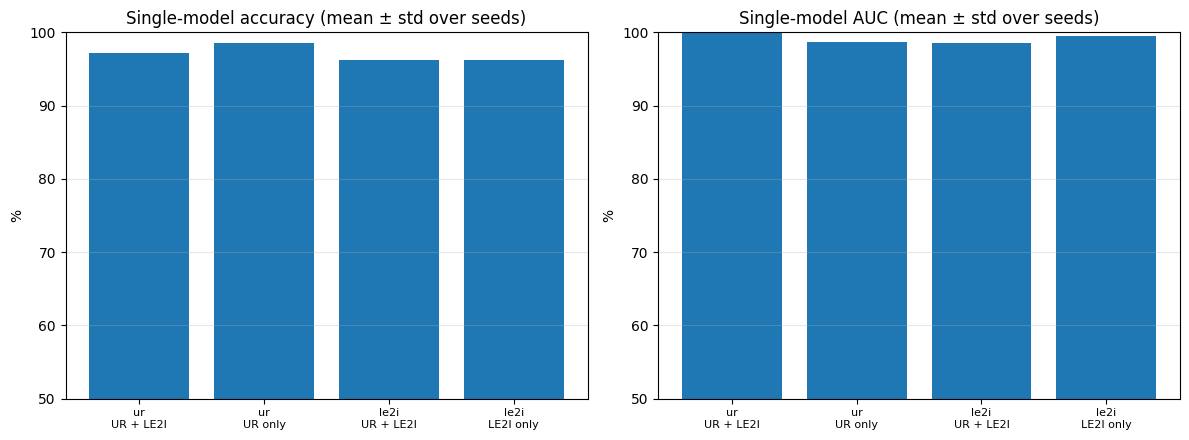

In [ ]:
# CELL 13 — ACCURACY REPORT (no timing) + SUMMARY FILE FOR THE ABLATION TABLE
METRIC_KEYS = ["accuracy", "precision", "recall", "specificity", "f1", "auc"]


def gather(exp, dataset=None):
    by_name = {}
    for seed, results in exp["results"].items():
        for r in results:
            d = r["test_pred"]
            for n_, y_, p_ in zip(d["names"], d["y"], d["prob"]):
                if dataset is None or dataset_by_sequence[n_] == dataset:
                    by_name.setdefault(n_, {"y": int(y_), "p": []})["p"].append(float(p_))
    names_ = sorted(by_name)
    return (names_, np.array([by_name[n_]["y"] for n_ in names_]),
            np.array([by_name[n_]["p"] for n_ in names_]))


def summarize(y, P, thr=FIXED_THRESHOLD):
    per_seed = [metrics_from_probs(y, P[:, k], thr) for k in range(P.shape[1])]
    mean = {k: float(np.mean([m[k] for m in per_seed])) for k in METRIC_KEYS}
    std = {k: float(np.std([m[k] for m in per_seed], ddof=1)) if len(per_seed) > 1 else float("nan")
           for k in METRIC_KEYS}
    return {"n": len(y), "per_seed": per_seed, "mean": mean, "std": std, "ens": metrics_from_probs(y, P.mean(axis=1), thr)}


def fmt(m):
    return (f"acc={m['accuracy']:.3f} prec={m['precision']:.3f} sens={m['recall']:.3f} "
            f"spec={m['specificity']:.3f} f1={m['f1']:.3f} auc={m['auc']:.3f}  (FP={m['fp']}, FN={m['fn']})")


summary_rows = {}
for mode in RUN_MODES:
    exp = experiments[mode]
    names_m, y_m, P_m = gather(exp)
    s = summarize(y_m, P_m)
    seeds_ = list(exp["results"].keys())
    print("\n" + "=" * 92)
    print(f"MODE '{mode}' — train {MODE_TRAIN[mode]} -> test {MODE_TEST[mode]} | {s['n']} test sequences | threshold {FIXED_THRESHOLD}")
    print("=" * 92)
    for k, seed in enumerate(seeds_):
        print(f"  seed {seed}: {fmt(s['per_seed'][k])}")
    if len(seeds_) > 1:
        for key in METRIC_KEYS:
            print(f"  {key:12s}: {s['mean'][key] * 100:6.2f}% ± {s['std'][key] * 100:5.2f}%")
    print(f"  seed ensemble: {fmt(s['ens'])}")
    wrong = ((P_m >= FIXED_THRESHOLD).astype(int) != y_m[:, None]).sum(axis=1)
    sysm = list(np.flatnonzero(wrong == len(seeds_)))
    print(f"  wrong in every seed: {len(sysm)} | in some: {int(((wrong > 0) & (wrong < len(seeds_))).sum())} | never: {int((wrong == 0).sum())}")
    for i in sysm:
        print(f"     {names_m[i]:<20} {dataset_by_sequence[names_m[i]]:<5} "
              f"{'missed fall' if y_m[i] == 1 else 'false alarm':<12} mean p(fall)={P_m[i].mean():.3f}")

print("\n" + "=" * 118)
print("COMPARISON — same test sequences, different training data")
print("=" * 118)
print(f"{'test on':<8}{'trained on':<20}{'n':>4} | {'single acc %':>14}{'single AUC %':>14} | {'ens acc':>8}{'sens':>7}{'spec':>7}{'AUC':>7}{'FP':>4}{'FN':>4}")
comparison_rows = []
for eval_ds in ("ur", "le2i"):
    for mode in RUN_MODES:
        if eval_ds not in MODE_TEST[mode]:
            continue
        _, y, P = gather(experiments[mode], eval_ds)
        s = summarize(y, P)
        e = s["ens"]
        train_label = " + ".join(d.upper() for d in MODE_TRAIN[mode]) + ("" if len(MODE_TRAIN[mode]) > 1 else " only")
        print(f"{eval_ds:<8}{train_label:<20}{s['n']:>4} | "
              f"{s['mean']['accuracy'] * 100:>7.2f} ±{s['std']['accuracy'] * 100:>4.1f}"
              f"{s['mean']['auc'] * 100:>8.2f} ±{s['std']['auc'] * 100:>4.1f} | "
              f"{e['accuracy']:>8.3f}{e['recall']:>7.3f}{e['specificity']:>7.3f}{e['auc']:>7.3f}{e['fp']:>4}{e['fn']:>4}")
        comparison_rows.append({"test": eval_ds, "trained_on": train_label, "summary": s})
        summary_rows.setdefault(mode, {})[eval_ds] = {
            "n": s["n"], "acc_mean": s["mean"]["accuracy"], "acc_std": s["std"]["accuracy"],
            "auc_mean": s["mean"]["auc"], "auc_std": s["std"]["auc"], "ens_acc": e["accuracy"],
            "ens_auc": e["auc"], "ens_fp": e["fp"], "ens_fn": e["fn"]}

if all(m in experiments for m in ("all", "ur", "le2i")):
    _, y_j, P_j = gather(experiments["all"])
    _, y_u, P_u = gather(experiments["ur"])
    _, y_l, P_l = gather(experiments["le2i"])
    print("-" * 118)
    for label, s in (("ALL trained jointly", summarize(y_j, P_j)),
                     ("ALL trained separately", summarize(np.concatenate([y_u, y_l]), np.vstack([P_u, P_l])))):
        e = s["ens"]
        print(f"{'both':<8}{label:<20}{s['n']:>4} | "
              f"{s['mean']['accuracy'] * 100:>7.2f} ±{s['std']['accuracy'] * 100:>4.1f}"
              f"{s['mean']['auc'] * 100:>8.2f} ±{s['std']['auc'] * 100:>4.1f} | "
              f"{e['accuracy']:>8.3f}{e['recall']:>7.3f}{e['specificity']:>7.3f}{e['auc']:>7.3f}{e['fp']:>4}{e['fn']:>4}")
    print("(separate-model AUC pools scores of two models: compare accuracy and per-dataset AUC)")

RUN_SUMMARY_PATH = EXPERIMENT_ROOT / f"{RUN_NAME}__summary.json"
with open(RUN_SUMMARY_PATH, "w") as f:
    json.dump({"run_name": RUN_NAME, "config": RUN_CONFIG, "results": summary_rows}, f, indent=1)
print("\nSummary written to", RUN_SUMMARY_PATH.name)

if PLOT_RESULTS and comparison_rows:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    labels_ = [f"{r['test']}\n{r['trained_on']}" for r in comparison_rows]
    for a, key, title in zip(ax, ["accuracy", "auc"], ["Single-model accuracy", "Single-model AUC"]):
        a.bar(range(len(comparison_rows)), [100 * r["summary"]["mean"][key] for r in comparison_rows],
              yerr=[100 * r["summary"]["std"][key] for r in comparison_rows], capsize=4)
        a.set_xticks(range(len(comparison_rows))); a.set_xticklabels(labels_, fontsize=8)
        a.set_ylim(50, 100); a.set_ylabel("%"); a.set_title(title + " (mean ± std over seeds)"); a.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


In [ ]:
# CELL 14 — ABLATION TABLE OVER ALL RUNS (run the notebook with different settings, then rerun this cell)
rows = []
for p in sorted(EXPERIMENT_ROOT.glob("*__summary.json")):
    with open(p) as f:
        s = json.load(f)
    c, r = s["config"], s["results"]

    def cell(mode, ds, key="acc_mean", scale=100.0):
        v = r.get(mode, {}).get(ds, {}).get(key)
        return f"{v * scale:6.1f}" if v is not None else "     -"

    rows.append((c["window_mode"] + (f"-{c['mil_pool']}" if c["window_mode"] == "mil" else ""), c["norm_scope"],
                 "+".join(c["aug_enable"]) if c["aug_enable"] else "none", "+".join(c["features"]),
                 cell("ur", "ur"), cell("le2i", "le2i"), cell("all", "ur"), cell("all", "le2i"),
                 cell("ur_to_le2i", "le2i"), cell("ur_to_le2i", "le2i", "auc_mean"),
                 cell("le2i_to_ur", "ur"), cell("le2i_to_ur", "ur", "auc_mean"), s["run_name"][-8:]))
print(f"{'window':<10}{'norm':<9}{'UR-only':>8}{'Le2i-only':>10}{'joint/UR':>9}{'joint/Le2i':>11}"
      f"{'UR>Le2i acc':>12}{'AUC':>7}{'Le2i>UR acc':>12}{'AUC':>7}  augmentations | run")
for w in sorted(rows, key=lambda x: (x[0], x[1], x[2])):
    print(f"{w[0]:<10}{w[1]:<9}{w[4]:>8}{w[5]:>10}{w[6]:>9}{w[7]:>11}{w[8]:>12}{w[9]:>7}{w[10]:>12}{w[11]:>7}  {w[2]} | {w[12]}")


window    norm      UR-only Le2i-only joint/UR joint/Le2i UR>Le2i acc    AUC Le2i>UR acc    AUC  augmentations | run
mil-topk  window       94.8      94.0     91.9       92.3           -      -           -      -  mirror | 8187bd85
mil-topk  window       95.2      94.9     91.0       93.6           -      -           -      -  mirror+rotate+axis_scale+shear+time_scale+time_warp+joint_noise+joint_dropout+frame_dropout | c778cb48
mil-topk  window       93.8      95.3     91.9       93.6           -      -           -      -  mirror+rotate+axis_scale+shear+time_scale+time_warp+joint_noise+joint_dropout+frame_dropout | e4c914e1
mil-topk  window       95.2      92.2     89.5       91.3           -      -           -      -  none | ba7cda02
none      sequence     94.3      94.5     90.5       92.3           -      -           -      -  mirror+joint_noise+joint_dropout+frame_dropout | 3500e007
none      sequence     98.6      96.2     97.1       96.2           -      -           -      -  mir

In [ ]:
''' # CELL 15 — OPTIONAL: EXPORT A TRAINED MODEL FOR THE EDGE DEVICE (ONNX + preprocessing constants)
EXPORT = False
EXPORT_MODE, EXPORT_SEED, EXPORT_FOLD = "all", SEEDS[0], 1

if EXPORT:
    exp = experiments[EXPORT_MODE]
    ck = torch.load(exp["ckpt_dir"] / f"seed{EXPORT_SEED}" / f"fold{EXPORT_FOLD}_best.pth",
                    map_location="cpu", weights_only=False)
    cpu = torch.device("cpu")
    model = make_model(cpu)
    model.load_state_dict(ck["model_state_dict"])
    model.eval()
    T_ex = WINDOW_LEN if WINDOW_MODE == "mil" else 150
    x, m = torch.zeros(1, INPUT_CHANNELS, T_ex), torch.ones(1, 1, T_ex)
    out_dir = exp["results_dir"] / "export"
    out_dir.mkdir(parents=True, exist_ok=True)
    meta = {
        "feature_names": SELECTED_FEATURE_NAMES, "kinds": [c[2] for c in _COLS],
        "mirror_sign": MIRROR_SIGN.tolist(), "channel_mean": ck["channel_mean"].tolist(),
        "channel_std": ck["channel_std"].tolist(), "target_fps": TARGET_FPS, "window_mode": WINDOW_MODE,
        "window_len": WINDOW_LEN, "window_stride": WINDOW_STRIDE, "mil_pool": MIL_POOL, "mil_k": MIL_K,
        "norm_scope": NORM_SCOPE, "min_scale_px": MIN_SCALE_PX, "mirror_tta": bool(USE_MIRROR_AUG and MIRROR_TTA),
        "note": "Network scores ONE window; slide windows over the stream and pool their fall-vs-ADL margins "
                "(logit1 - logit0) with mil_pool. Features use a 3-frame look-ahead (Savitzky-Golay, window 7)."}
    with open(out_dir / "preprocessing.json", "w") as f:
        json.dump(meta, f, indent=1)
    torch.save(ck["model_state_dict"], out_dir / "trunk_tcn_state_dict.pt")
    try:
        try:
            torch.onnx.export(model, (x, m), str(out_dir / "trunk_tcn.onnx"), input_names=["x", "mask"],
                              output_names=["logits"], opset_version=17, dynamo=False,
                              dynamic_axes={"x": {0: "batch", 2: "time"}, "mask": {0: "batch", 2: "time"},
                                            "logits": {0: "batch"}})
        except TypeError:
            torch.onnx.export(model, (x, m), str(out_dir / "trunk_tcn.onnx"), input_names=["x", "mask"],
                              output_names=["logits"], opset_version=17,
                              dynamic_axes={"x": {0: "batch", 2: "time"}, "mask": {0: "batch", 2: "time"},
                                            "logits": {0: "batch"}})
        print("Exported to", out_dir)
    except Exception as exc:
        print("ONNX export failed (", type(exc).__name__, exc, ") - state dict and preprocessing.json were saved.")
 '''

' # CELL 15 — OPTIONAL: EXPORT A TRAINED MODEL FOR THE EDGE DEVICE (ONNX + preprocessing constants)\nEXPORT = False\nEXPORT_MODE, EXPORT_SEED, EXPORT_FOLD = "all", SEEDS[0], 1\n\nif EXPORT:\n    exp = experiments[EXPORT_MODE]\n    ck = torch.load(exp["ckpt_dir"] / f"seed{EXPORT_SEED}" / f"fold{EXPORT_FOLD}_best.pth",\n                    map_location="cpu", weights_only=False)\n    cpu = torch.device("cpu")\n    model = make_model(cpu)\n    model.load_state_dict(ck["model_state_dict"])\n    model.eval()\n    T_ex = WINDOW_LEN if WINDOW_MODE == "mil" else 150\n    x, m = torch.zeros(1, INPUT_CHANNELS, T_ex), torch.ones(1, 1, T_ex)\n    out_dir = exp["results_dir"] / "export"\n    out_dir.mkdir(parents=True, exist_ok=True)\n    meta = {\n        "feature_names": SELECTED_FEATURE_NAMES, "kinds": [c[2] for c in _COLS],\n        "mirror_sign": MIRROR_SIGN.tolist(), "channel_mean": ck["channel_mean"].tolist(),\n        "channel_std": ck["channel_std"].tolist(), "target_fps": TARGET_FPS, "win